# Analytic Task 3– Possession Interception Analysis

## Analytic Question

Do teams with below-median possession and teams with above-median possession differ significantly in their mean interceptions per 90 minutes at the FIFA World Cup 2026

The teams with lower possessio spend more time without the ball, which may create more chances to intercept the passess from the opponents. But the teams with more possession spend more time controlling the ball and have fewer interceptions per 90 minutes. Thus this analysis tests whether the difference in the defensive interception activity between the two teams is statistically significant.

## Data Source

The data for this analysis will be obtained from FBref's FIFA World Cup 2026 Squad Possession Statistics, and the miscellaneous stats, two of the approved data sources in the project brief.

The main variables required are:

Poss – average team possession percentage ,
90s – total team playing time measured in 90-minute units ,
Squad- Team name
Int- Total interceptions

New variable, Interceptions_per_90 will be created in Python.
Interceptions per 90 = Total Interceptions/90

Teams were then divided using the median possession value of the tournament which is 49.8% and the teams with exactly median possession were excluded.

In [2]:
import pandas as pd

In [5]:
possession = pd.read_clipboard(sep=',')

possession.head()

,Squad,# Pl,Poss,90s,Touches,Def Pen,Def 3rd,Mid 3rd,Att 3rd,Att Pen,...,Tkld,Tkld%,Carries,TotDist,PrgDist,1/3,CPA,Mis,Dis,Rec
0,dz Algeria,22,61.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ar Argentina,24,57.6,9.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,au Australia,23,41.0,4.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,at Austria,20,45.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,be Belgium,23,51.2,6.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
misc = pd.read_clipboard(sep=',')

misc.head()

,Squad,# Pl,90s,CrdY,CrdR,2CrdY,Fls,Fld,Off,Crs,Int,TklW,PKwon,PKcon,OG
0,dz Algeria,22,4.0,3,0,0,29,40,4,40,30,44,NaN,NaN,0
1,ar Argentina,24,9.0,15,1,1,113,100,22,104,82,93,NaN,NaN,0
2,au Australia,23,4.3,5,0,0,46,38,1,70,29,34,NaN,NaN,1
3,at Austria,20,4.0,5,0,0,47,28,11,59,41,29,NaN,NaN,0
4,be Belgium,23,6.3,6,1,0,78,68,8,114,50,47,NaN,NaN,0


In [7]:
misc.columns.tolist()

['Squad',
 '# Pl',
 '90s',
 'CrdY',
 'CrdR',
 '2CrdY',
 'Fls',
 'Fld',
 'Off',
 'Crs',
 'Int',
 'TklW',
 'PKwon',
 'PKcon',
 'OG']

In [8]:
misc_small = misc[['Squad', '90s', 'Int']].copy()

misc_small.head()

,Squad,90s,Int
0,dz Algeria,4.0,30
1,ar Argentina,9.0,82
2,au Australia,4.3,29
3,at Austria,4.0,41
4,be Belgium,6.3,50


In [9]:
possession_small = possession[['Squad', 'Poss', '90s']].copy()

possession_small.head()

,Squad,Poss,90s
0,dz Algeria,61.0,4.0
1,ar Argentina,57.6,9.0
2,au Australia,41.0,4.3
3,at Austria,45.0,4.0
4,be Belgium,51.2,6.3


In [10]:
team_data = pd.merge(
    possession_small,
    misc_small,
    on='Squad',
    how='inner',
    suffixes=('_poss', '_misc')
)

team_data.head()

,Squad,Poss,90s_poss,90s_misc,Int
0,dz Algeria,61.0,4.0,4.0,30
1,ar Argentina,57.6,9.0,9.0,82
2,au Australia,41.0,4.3,4.3,29
3,at Austria,45.0,4.0,4.0,41
4,be Belgium,51.2,6.3,6.3,50


In [11]:
print("Rows:", team_data.shape[0])
print("Columns:", team_data.shape[1])

team_data.columns.tolist()

Rows: 48
Columns: 5


['Squad', 'Poss', '90s_poss', '90s_misc', 'Int']

In [12]:
(team_data['90s_poss'] == team_data['90s_misc']).value_counts()

True    48
Name: count, dtype: int64

In [13]:
team_data = team_data.drop(columns=['90s_misc'])
team_data = team_data.rename(columns={'90s_poss': '90s'})

team_data.head()

,Squad,Poss,90s,Int
0,dz Algeria,61.0,4.0,30
1,ar Argentina,57.6,9.0,82
2,au Australia,41.0,4.3,29
3,at Austria,45.0,4.0,41
4,be Belgium,51.2,6.3,50


In [14]:
team_data['Interceptions_per_90'] = (
    team_data['Int'] / team_data['90s']
)

team_data[['Squad', 'Poss', '90s', 'Int', 'Interceptions_per_90']].head()

,Squad,Poss,90s,Int,Interceptions_per_90
0,dz Algeria,61.0,4.0,30,7.500000
1,ar Argentina,57.6,9.0,82,9.111111
2,au Australia,41.0,4.3,29,6.744186
3,at Austria,45.0,4.0,41,10.250000
4,be Belgium,51.2,6.3,50,7.936508


In [15]:
median_possession = team_data['Poss'].median()

print("Median possession:", median_possession)

Median possession: 49.8


In [18]:
import numpy as np

In [19]:
team_data['Possession_Group'] = np.where(
    team_data['Poss'] < median_possession,
    'Below Median',
    'Above Median'
)

team_data['Possession_Group'].value_counts()

Possession_Group
Above Median    25
Below Median    23
Name: count, dtype: int64

In [20]:
team_data[team_data['Poss'] == median_possession][['Squad', 'Poss']]

,Squad,Poss
11,ci Côte d'Ivoire,49.8
12,hr Croatia,49.8


In [21]:
team_analysis = team_data[
    team_data['Poss'] != median_possession
].copy()

team_analysis['Possession_Group'] = np.where(
    team_analysis['Poss'] < median_possession,
    'Below Median',
    'Above Median'
)

team_analysis['Possession_Group'].value_counts()

Possession_Group
Above Median    23
Below Median    23
Name: count, dtype: int64

In [22]:
team_analysis[
    ['Squad', 'Poss', '90s', 'Int', 'Interceptions_per_90', 'Possession_Group']
].isnull().sum()

Squad                   0
Poss                    0
90s                     0
Int                     0
Interceptions_per_90    0
Possession_Group        0
dtype: int64

In [24]:
possession.to_csv(
    '/Users/apuu/Desktop/Data_Science_Assessment2/Data/raw/team_possession_raw.csv',
    index=False
)

misc.to_csv(
    '/Users/apuu/Desktop/Data_Science_Assessment2/Data/raw/team_misc_raw.csv',
    index=False
)

In [26]:
team_analysis.to_csv(
    '/Users/apuu/Desktop/Data_Science_Assessment2/Data/cleaned/task3_team_interceptions_cleaned.csv',
    index=False
)

In [27]:
below_sample = team_analysis[
    team_analysis['Possession_Group'] == 'Below Median'
].sample(n=20, random_state=42)

above_sample = team_analysis[
    team_analysis['Possession_Group'] == 'Above Median'
].sample(n=20, random_state=42)

task3_sample = pd.concat([below_sample, above_sample])

task3_sample['Possession_Group'].value_counts()

Possession_Group
Below Median    20
Above Median    20
Name: count, dtype: int64

In [29]:
task3_sample.to_csv(
    '/Users/apuu/Desktop/Data_Science_Assessment2/Data/cleaned/task3_sample_40_teams.csv',
    index=False
)

In [30]:
task3_summary = task3_sample.groupby('Possession_Group')['Interceptions_per_90'].agg(
    ['count', 'mean', 'median', 'std', 'var', 'min', 'max']
)

task3_summary

,count,mean,median,std,var,min,max
Possession_Group,,,,,,,
Above Median,20,7.684483,7.204651,1.617499,2.616303,5.813953,12.0
Below Median,20,8.850194,8.750000,2.205933,4.866140,4.750000,13.0


In [31]:
quartiles = task3_sample.groupby('Possession_Group')['Interceptions_per_90'].quantile([0.25, 0.75]).unstack()

quartiles.columns = ['Q1', 'Q3']
quartiles['IQR'] = quartiles['Q3'] - quartiles['Q1']

quartiles

,Q1,Q3,IQR
Possession_Group,,,
Above Median,6.587302,8.169222,1.58192
Below Median,7.729167,10.354167,2.62500


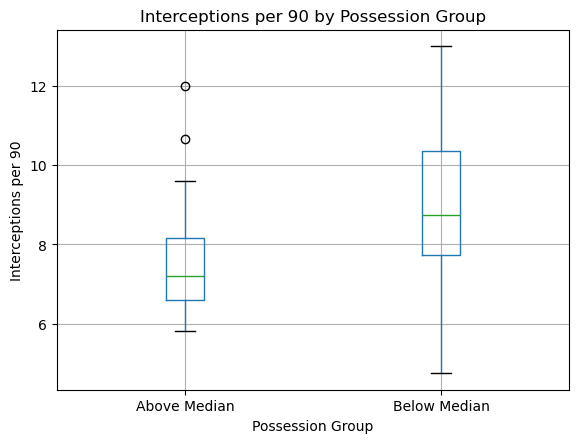

In [32]:
import matplotlib.pyplot as plt

task3_sample.boxplot(
    column='Interceptions_per_90',
    by='Possession_Group'
)

plt.title('Interceptions per 90 by Possession Group')
plt.suptitle('')
plt.xlabel('Possession Group')
plt.ylabel('Interceptions per 90')

plt.savefig(
    '/Users/apuu/Desktop/Data_Science_Assessment2/figure/task3_interceptions_boxplot.png',
    bbox_inches='tight'
)

plt.show()

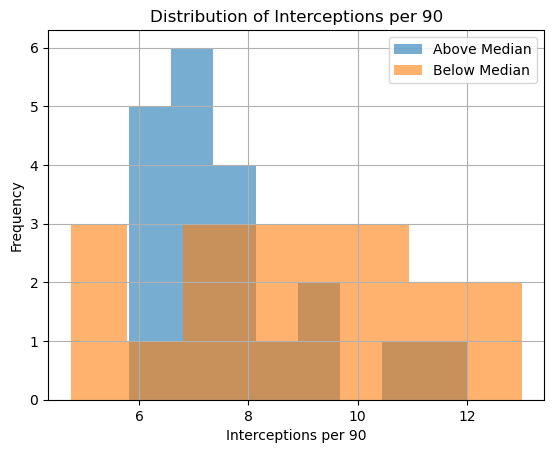

In [34]:
task3_sample[
    task3_sample['Possession_Group'] == 'Above Median'
]['Interceptions_per_90'].hist(alpha=0.6, bins=8, label='Above Median')

task3_sample[
    task3_sample['Possession_Group'] == 'Below Median'
]['Interceptions_per_90'].hist(alpha=0.6, bins=8, label='Below Median')

plt.title('Distribution of Interceptions per 90')
plt.xlabel('Interceptions per 90')
plt.ylabel('Frequency')
plt.legend()

plt.savefig(
    '/Users/apuu/Desktop/Data_Science_Assessment2/figure/task3_interceptions_histogram.png',
    bbox_inches='tight'
)

plt.show()

In [35]:
task3_skewness = task3_sample.groupby(
    'Possession_Group'
)['Interceptions_per_90'].skew()

task3_skewness

Possession_Group
Above Median    1.287222
Below Median   -0.089727
Name: Interceptions_per_90, dtype: float64

In [36]:
from scipy import stats

above = task3_sample[
    task3_sample['Possession_Group'] == 'Above Median'
]['Interceptions_per_90']

below = task3_sample[
    task3_sample['Possession_Group'] == 'Below Median'
]['Interceptions_per_90']

above_ci = stats.t.interval(
    confidence=0.95,
    df=len(above)-1,
    loc=above.mean(),
    scale=stats.sem(above)
)

below_ci = stats.t.interval(
    confidence=0.95,
    df=len(below)-1,
    loc=below.mean(),
    scale=stats.sem(below)
)

print("Above Median 95% CI:", above_ci)
print("Below Median 95% CI:", below_ci)

Above Median 95% CI: (np.float64(6.927470179244384), np.float64(8.441495953574991))
Below Median 95% CI: (np.float64(7.817785464831353), np.float64(9.88260213206787))


In [37]:
t_stat, p_value = stats.ttest_ind(
    below,
    above,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 1.9058296798744796
p-value: 0.06494775720899712


### Hypotheses

**Null hypothesis (H₀):**  
There is no difference in the mean interceptions per 90 minutes between below-median and above-median possession teams.

**Alternative hypothesis (H₁):**  
There is a difference in the mean interceptions per 90 minutes between below-median and above-median possession teams.

**Significance level:** α = 0.05

### Two-Sample t-Test Interpretation

An independent two-sample t-test was used to compare mean interceptions per 90 minutes between below-median and above-median possession teams.

The below-median possession group had a higher sample mean of 8.85 interceptions per 90,  with 7.68 for the above-median possession group.

The test had a t-statistic of 1.906 and a p-value of 0.0649. Since the p-value was greater than the 0.05 significance level, the null hypothesis was not rejected.

Therefore, although lower-possession teams recorded more interceptions per 90 in the sample, there was insufficient statistical evidence to conclude that the two possession groups differed significantly in their population mean interceptions per 90.

### Population and Sampling

The original joined dataset contained 48 FIFA World Cup 2026 teams. Two teams with possession exactly equal to the median value of 49.8% were excluded, leaving 46 eligible teams: 23 below the median and 23 above the median.

To satisfy the sampling requirement, stratified random sampling was used to select 20 teams from each possession group. A fixed random seed (random_state=42) was used so that the sample could be reproduced.

The final sample therefore contained 40 teams:
- 20 below-median possession teams
- 20 above-median possession teams

### Descriptive Statistics

The below-median possession teams recorded a higher average number of interceptions per 90 minutes than the above-median possession teams.

For the below-median group, the mean was 8.85 interceptions per 90 and the median was 8.75. The standard deviation was 2.21, with an interquartile range of 2.63.

For the above-median group, the mean was 7.68 interceptions per 90 and the median was 7.20. The standard deviation was 1.62, with an interquartile range of 1.58.

These results suggest that lower-possession teams recorded more interceptions per 90 on average, while their interception rates also showed greater variability.

### 95% Confidence Intervals

The 95% confidence interval for the above-median possession group was 6.93 to 8.44 interceptions per 90 minutes.

The 95% confidence interval for the below-median possession group was 7.82 to 9.88 interceptions per 90 minutes.

The intervals overlap, indicating that the difference between the two group means may not be statistically significant. This was tested formally using an independent two-sample t-test.

### Assumption Check

The below-median possession group had a skewness value of -0.09, indicating an approximately symmetric distribution. The above-median possession group had a skewness value of 1.29, indicating some right skewness.

Because both groups contained 20 teams and the samples were balanced, the independent two-sample t-test was still used. However, the skewness in the above-median group should be considered when interpreting the result.

The analysis used equal_var=False, so the test did not assume that the two groups had exactly equal variances.

### Data Wrangling and Preparation

The FBref Squad Possession and Squad Miscellaneous datasets were imported into Python and reduced to the variables required for the analysis.

The two datasets were joined using Squad as the common key. The join produced 48 matched teams, and the 90s values from both datasets were checked and found to match for all 48 teams.

A new variable, Interceptions_per_90, was created by dividing total interceptions (Int) by playing time (90s). The median possession value was then calculated as 49.8%.

Two teams with possession exactly equal to 49.8% were excluded so that the comparison contained only clearly above-median and below-median teams. The remaining analysis dataset contained 46 teams and had no missing values in the variables used for the analysis.

### Conclusion and Limitations

Below-median possession teams recorded a higher sample mean of 8.85 interceptions per 90 minutes compared with 7.68 for above-median possession teams.

However, the independent two-sample t-test produced a p-value of 0.0649, which was greater than the 0.05 significance level. Therefore, the null hypothesis was not rejected, and there was insufficient evidence to conclude that the two possession groups differed significantly in their mean interceptions per 90 minutes.

One limitation is that the above-median group showed some right skewness. In addition, team statistics were accumulated across different numbers of matches, although using interceptions per 90 helped adjust for differences in playing time.

In [39]:
task3_summary_final = task3_summary.copy()

task3_summary_final['Q1'] = quartiles['Q1']
task3_summary_final['Q3'] = quartiles['Q3']
task3_summary_final['IQR'] = quartiles['IQR']

task3_summary_final.loc['Above Median', 'CI_Lower'] = above_ci[0]
task3_summary_final.loc['Above Median', 'CI_Upper'] = above_ci[1]

task3_summary_final.loc['Below Median', 'CI_Lower'] = below_ci[0]
task3_summary_final.loc['Below Median', 'CI_Upper'] = below_ci[1]

task3_summary_final.to_csv(
    '/Users/apuu/Desktop/Data_Science_Assessment2/Data/cleaned/task3_summary_table.csv'
)

task3_summary_final

,count,mean,median,std,var,min,max,Q1,Q3,IQR,CI_Lower,CI_Upper
Possession_Group,,,,,,,,,,,,
Above Median,20,7.684483,7.204651,1.617499,2.616303,5.813953,12.0,6.587302,8.169222,1.58192,6.927470,8.441496
Below Median,20,8.850194,8.750000,2.205933,4.866140,4.750000,13.0,7.729167,10.354167,2.62500,7.817785,9.882602
